# 2.8 Gaussian city with relocations

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from city_simulator import City

# Integration test (no figures saved)

2025-10-17 09:50:27,417 - INFO - Initializing city
2025-10-17 09:50:27,419 - INFO - Calculating density profile for 1 core(s)
2025-10-17 09:50:27,425 - INFO - Running simulation for 5000 steps
2025-10-17 09:50:30,219 - INFO - Simulation completed in 2.79 seconds
2025-10-17 09:50:30,220 - INFO - In-simulation time passed: 17 days
2025-10-17 09:50:30,221 - INFO - Overall, statistics gathered over: 7 days
2025-10-17 09:50:30,221 - INFO - Cumulative rentals happened: 19190
2025-10-17 09:50:30,222 - INFO - Average rentals per car per day: 5.53
2025-10-17 09:50:30,223 - INFO - Average rental time per trip, min: 17.57
2025-10-17 09:50:30,223 - INFO - Average CM1 profit per trip, Eur: 4.39
2025-10-17 09:50:30,224 - INFO - Overall CM2 profit per day, Eur: 2138.05
2025-10-17 09:50:30,225 - INFO - Average relocations per day: 1.87


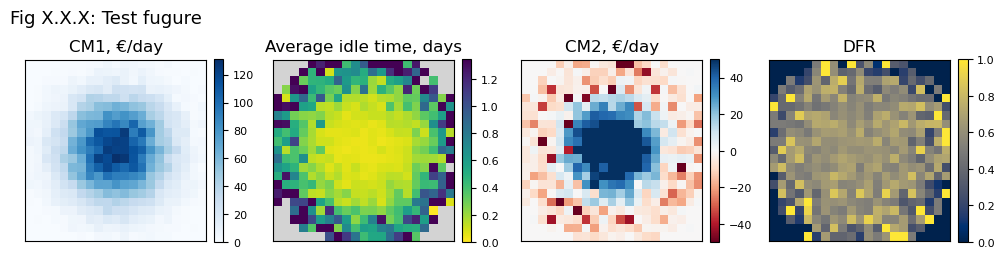

In [2]:
# Testing grounds, not a real figure
config = {
    "seed": 1,  # Random seed
    "initial_r": 10, # km
    "grid_step": 1, # km. Use 1 for ~intermediate resolution
    "n_cars": 500,
    "settle_down_steps": 3000, # Number of steps without stats collection, for the system to settle down
}

# To be able to re-run this one cell only, repeat package imports here
import matplotlib.pyplot as plt
from city_simulator import City

city = City(config)
city.init_cars()
city.simulate(5000)
plt.figure(figsize=(10, 5))
city.visualize(plots=["cm1", "idle_times", "cm2", "dfr"], title="Fig X.X.X: Test fugure")

In [3]:
stop_here()  # Intentional crash against "run all" overwriting everything

NameError: name 'stop_here' is not defined

# Blurring cars and demand

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

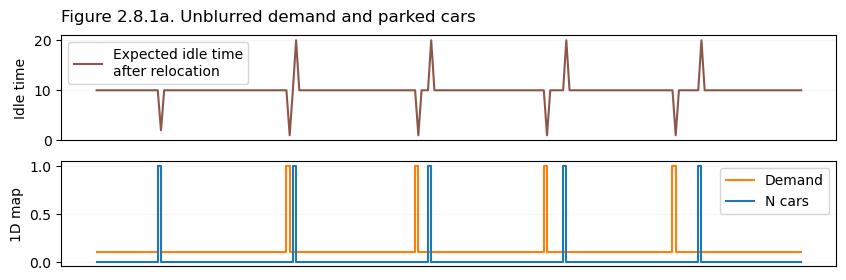

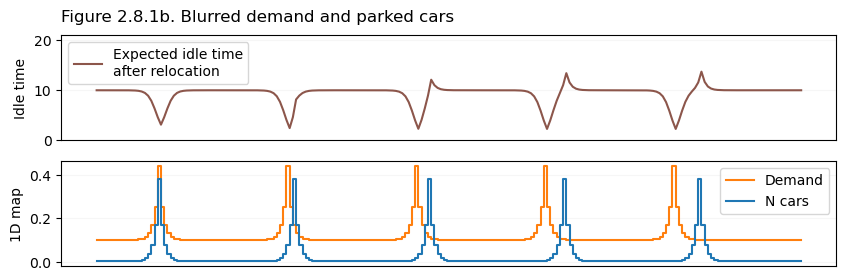

In [ ]:
# Create a good 1D testing set of n_cars values
plot_length = 220
plot_step = 40
n_cars = np.zeros(plot_length)
demand = np.ones(plot_length)*1e-1
# Place a car at every 10th pixel starting from 5
demand[(plot_step//2):plot_length:plot_step] = 1
n_cars[(plot_step//2):plot_length:(plot_step+2)] = 1

def blur_figure(demand, n_cars, title=""):
    plt.figure(figsize=(10, 3))
    plt.subplot(211)
    plt.title(title, loc="left", pad=10)
    plt.plot((n_cars+1)/demand, '-', color="tab:brown",
             label="Expected idle time\nafter relocation")
    plt.legend(loc='upper left')
    plt.ylim(0, 21); plt.ylabel("Idle time"); plt.grid(alpha=0.1)
    plt.xticks([])

    plt.subplot(212)
    plt.step(demand, '-', label="Demand", color="tab:orange")
    plt.step(n_cars, '-', label="N cars", color="tab:blue")
    # plt.yticks([]);
    plt.legend(); plt.xticks([]); plt.ylabel("1D map"); plt.grid(alpha=0.1)

    # plt.tight_layout()

blur_figure(demand, n_cars, "Figure 2.8.1a. Unblurred demand and parked cars")
plt.savefig("../figures/02relos_08city_01a.svg", dpi=300)

# Time to blur everything
f = lambda x: np.exp(-abs(x*0.8))
kernel = f(np.arange(-plot_step, plot_step+1))
kernel = kernel / np.sum(kernel)

# Convolve demand with kernel f (pad with edge values on both sides)
demand = np.pad(demand, (plot_step, plot_step), mode='edge')
demand = np.convolve(demand, kernel, mode='same')
demand = demand[plot_step:-plot_step]  # unpad
n_cars = np.convolve(n_cars, kernel, mode='same')

blur_figure(demand, n_cars, "Figure 2.8.1b. Blurred demand and parked cars")
plt.savefig("../figures/02relos_08city_01b.svg", dpi=300)

2025-10-17 09:52:29,548 - INFO - Initializing city
2025-10-17 09:52:29,552 - INFO - Calculating density profile for 1 core(s)


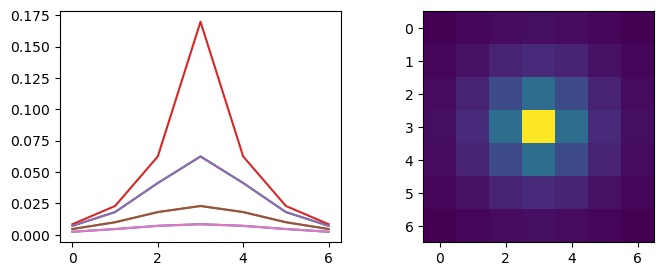

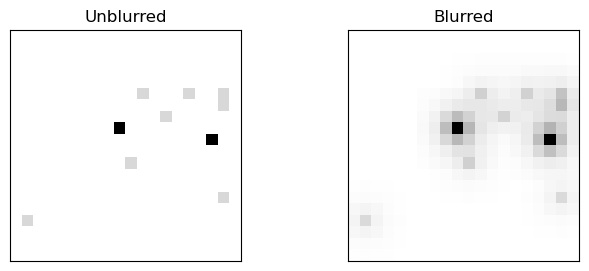

In [8]:
# Test blur kernel from the city simulator
import numpy as np
from scipy.signal import convolve2d
import matplotlib.pyplot as plt
from city_simulator import City
config = {
    "seed": 1,  # Random seed
    "initial_r": 10, # km
    "grid_step": 0.3, # km. Use 1 for ~intermediate resolution
    "n_cars": 500,
    "settle_down_steps": 3000, # Number of steps without stats collection, for the system to settle down
}

city = City(config)

plt.figure(figsize=(8,3))
plt.subplot(121)
plt.plot(city.blur_kernel)
plt.subplot(122)
plt.imshow(city.blur_kernel, cmap='viridis')

# Test demand profile: a 20x20 empty grid with a few random points
demand = np.zeros((20, 20), dtype=np.float32)
for i in range(10):
    x, y = np.random.randint(0, 20, size=2)
    demand[x, y] = np.random.randint(1, 5)
plt.figure(figsize=(8,3))
plt.subplot(121)
plt.imshow(demand, cmap="Grays"); plt.title("Unblurred");
plt.xticks([]); plt.yticks([])
plt.subplot(122)
demand = convolve2d(demand, city.blur_kernel, mode='same', boundary='fill', fillvalue=0)
plt.imshow(demand, cmap="Grays"); plt.title("Blurred")
plt.xticks([]); plt.yticks([]);

# Typical stats - base state (no relocations, no price shenanigans, one core)

2025-10-17 10:02:33,261 - INFO - Initializing city
2025-10-17 10:02:33,264 - INFO - Calculating density profile for 1 core(s)
2025-10-17 10:02:33,276 - INFO - Running simulation for 10000 steps
2025-10-17 10:02:35,715 - INFO - ..Simulating step 5000 of 10000
2025-10-17 10:02:38,457 - INFO - Simulation completed in 5.18 seconds
2025-10-17 10:02:38,457 - INFO - In-simulation time passed: 35 days
2025-10-17 10:02:38,459 - INFO - Overall, statistics gathered over: 24 days
2025-10-17 10:02:38,460 - INFO - Cumulative rentals happened: 49571
2025-10-17 10:02:38,461 - INFO - Average rentals per car per day: 4.08
2025-10-17 10:02:38,463 - INFO - Average rental time per trip, min: 17.64
2025-10-17 10:02:38,463 - INFO - Average CM1 profit per trip, Eur: 4.41
2025-10-17 10:02:38,464 - INFO - Overall CM2 profit per day, Eur: -1006.29
2025-10-17 10:02:38,465 - INFO - Average relocations per day: 0.00
2025-10-17 10:02:38,574 - INFO - Initializing city
2025-10-17 10:02:38,575 - INFO - Calculating dens

Creating a 2nd city now...


2025-10-17 10:02:41,215 - INFO - ..Simulating step 5000 of 10000
2025-10-17 10:02:44,332 - INFO - Simulation completed in 5.75 seconds
2025-10-17 10:02:44,333 - INFO - In-simulation time passed: 35 days
2025-10-17 10:02:44,333 - INFO - Overall, statistics gathered over: 24 days
2025-10-17 10:02:44,334 - INFO - Cumulative rentals happened: 52563
2025-10-17 10:02:44,335 - INFO - Average rentals per car per day: 4.33
2025-10-17 10:02:44,335 - INFO - Average rental time per trip, min: 17.51
2025-10-17 10:02:44,336 - INFO - Average CM1 profit per trip, Eur: 4.38
2025-10-17 10:02:44,336 - INFO - Overall CM2 profit per day, Eur: -534.61
2025-10-17 10:02:44,337 - INFO - Average relocations per day: 10.70


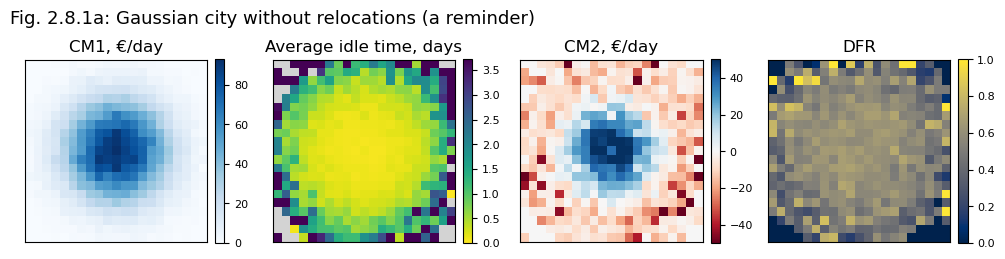

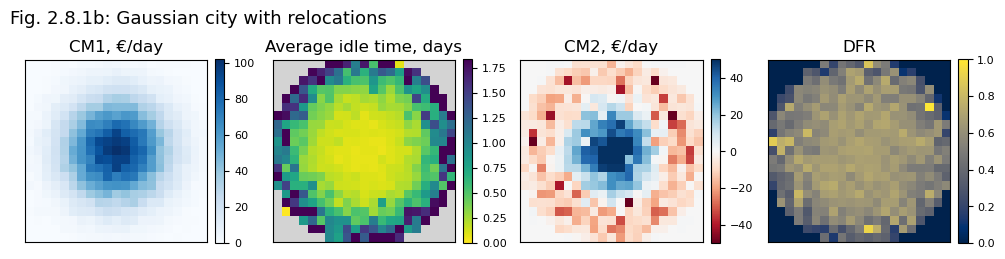

In [9]:
# Nice city
config = {
    "seed": 1,  # Random seed
    "grid_step": 1, # km. Use 1 for ~intermediate resolution
    "n_cars": 500,
    "p_factor": 0.15, # Bring the rentals/car/day to about 4
    "settle_down_steps": 3000, # Number of steps without stats collection, for the system to settle down
    "do_flatten_demand": False,
    "do_relocations": False,
    "relo_cost": 10,
}

import numpy as np
import matplotlib.pyplot as plt
from city_simulator import City

city0 = City(config)
city0.init_cars()
city0.simulate(10000)

plt.figure(figsize=(10, 5))
city0.visualize(
    plots=["cm1", "idle_times", "cm2", "dfr"],
    title="Fig. 2.8.1a: Gaussian city without relocations (a reminder)"
)
# plt.savefig("../figures/02relos_08city_01control.svg", dpi=300)

print("Creating a 2nd city now...")
config["do_relocations"] = True
city1 = City(config)
city1.init_cars()
city1.simulate(10000)

plt.figure(figsize=(10, 5))
city1.visualize(
    plots=["cm1", "idle_times", "cm2", "dfr"],
    title="Fig. 2.8.1b: Gaussian city with relocations"
)
# plt.savefig("../figures/02relos_08city_02relocations.svg", dpi=300)

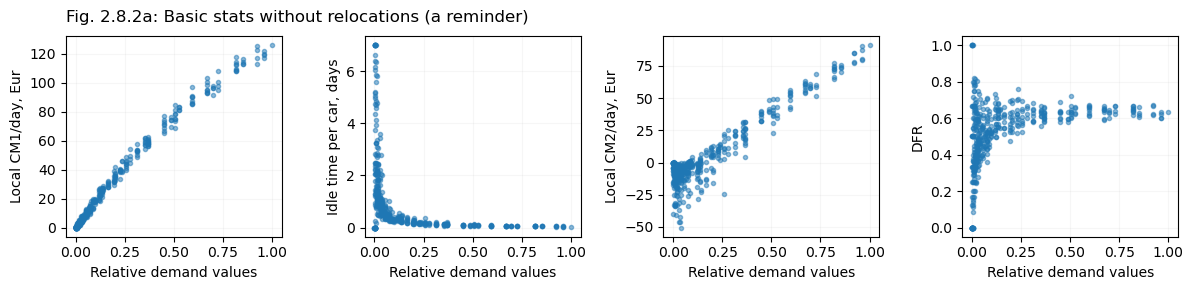

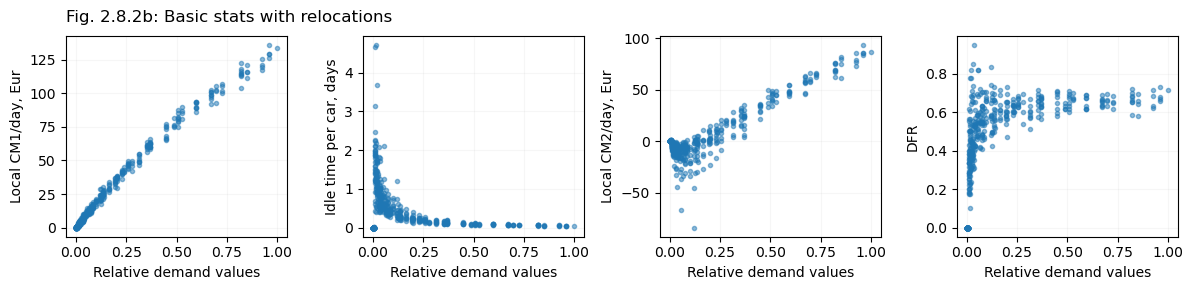

In [15]:
# Stats, use data from the previous run 👆

def extract_values(city):
    """Helper function to prep data for plots."""
    demand = city.demand.flatten()
    cm1 = city.map_cm1.flatten() / city.n_days
    cm2 = city.map_cm2.flatten() / city.n_days
    idle_times = city.map_idle_time.flatten() * city.tick_in_minutes / 60 / 24 / np.maximum(1, city.map_n_rentals.flatten())
    dfr = city.map_n_rentals.flatten() / np.maximum(1, city.map_n_appops.flatten())
    return demand, cm1, cm2, idle_times, dfr

def simple_stats_figure(city, title):
    demand, cm1, cm2, idle_times, dfr = extract_values(city)

    plt.figure(figsize=(12, 3))
    plt.subplot(141)
    plt.title(title, loc='left', pad=10);
    plt.plot(demand, cm1, '.', alpha=0.5)
    plt.grid(alpha=0.1)
    plt.xlabel("Relative demand values")
    plt.ylabel("Local CM1/day, Eur")

    plt.subplot(142)
    plt.plot(demand, np.minimum(7, idle_times), '.', alpha=0.5)
    plt.grid(alpha=0.1)
    plt.xlabel("Relative demand values")
    plt.ylabel("Idle time per car, days")

    plt.subplot(143)
    plt.plot(demand, cm2, '.', alpha=0.5)
    plt.grid(alpha=0.1)
    plt.xlabel("Relative demand values")
    plt.ylabel("Local CM2/day, Eur")

    plt.subplot(144)
    plt.plot(demand, dfr, '.', alpha=0.5)
    plt.grid(alpha=0.1)
    plt.xlabel("Relative demand values")
    plt.ylabel("DFR")

    plt.tight_layout();

simple_stats_figure(city0, "Fig. 2.8.2a: Basic stats without relocations (a reminder)")
# plt.savefig("../figures/02relos_08city_03control_stats.svg", dpi=300)
simple_stats_figure(city1, "Fig. 2.8.2b: Basic stats with relocations")

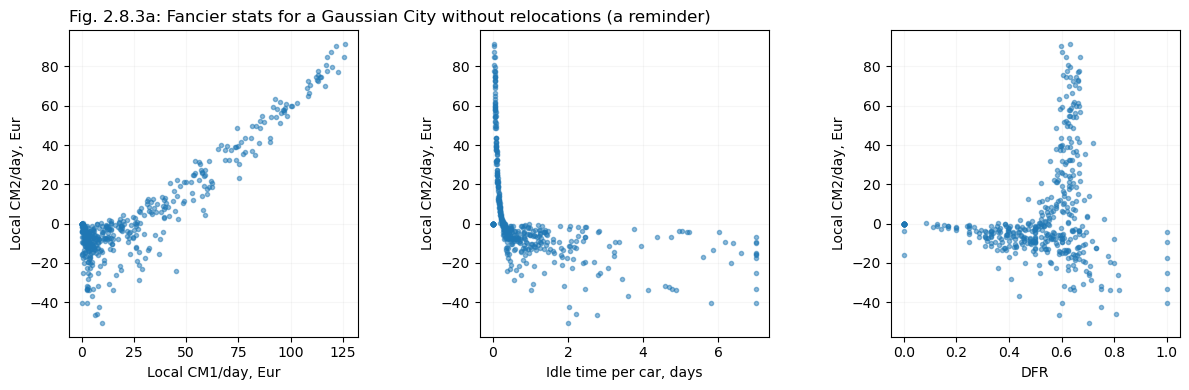

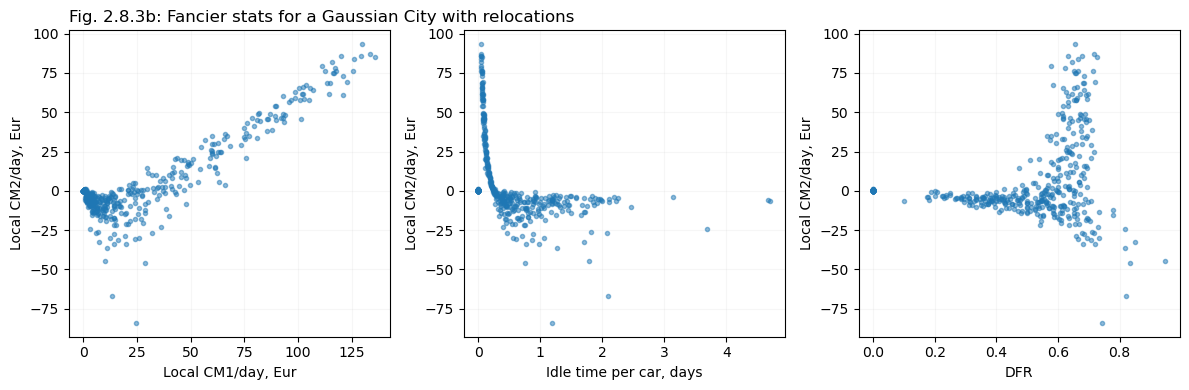

In [ ]:
# Fancier stats (from the same run)

def fancier_figure(city, title):
    demand, cm1, cm2, idle_times, dfr = extract_values(city)
    plt.figure(figsize=(12, 4))
    plt.subplot(131)
    plt.title(title, loc='left');
    plt.plot(cm1, cm2, '.', alpha=0.5)
    plt.grid(alpha=0.1)
    plt.ylabel("Local CM2/day, Eur")
    plt.xlabel("Local CM1/day, Eur")

    plt.subplot(132)
    plt.plot(np.minimum(idle_times, 7), cm2, '.', alpha=0.5)
    plt.grid(alpha=0.1)
    plt.xlabel("Idle time per car, days")
    plt.ylabel("Local CM2/day, Eur")

    plt.subplot(133)
    plt.plot(dfr, cm2, '.', alpha=0.5)
    plt.grid(alpha=0.1)
    plt.xlabel("DFR")
    plt.ylabel("Local CM2/day, Eur")

    plt.tight_layout();

fancier_figure(city0, "Fig. 2.8.3a: Fancier stats for a Gaussian City without relocations (a reminder)")
fancier_figure(city1, "Fig. 2.8.3b: Fancier stats for a Gaussian City with relocations")
# plt.savefig("../figures/01simple_03city_06stats2_plots.svg", dpi=300)